# Concept: Burst Search

This notebook describes the organization and behavior of the `Bursts` table.

The cell below loads a test data set with which to deomonstrate the burst search behaviors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf
import smfbursts.cfuncs as smc # this is for calling C-optimized functions for internal calls

## Basic Burst Search

The `Bursts` table provides the basic burst search functionality.

### Burst Search Algorithm

The sliding window burst search algorithm uses the eponymous "sliding window" to compute an pseudo-instantaneous rate photon rate, 
and select the ranges in time where the instantaneous rate is above some threshold multiplier of the background.

Consider the data as a set of photon arrival times 
$T = \{t_{0}, t_{1}, ... t_{N}\}$.

We define a sliding window of size $m$ as photons with indexes from $\{t_{i}, ... t_{i+m}\}$

Therefore there are $N-m$ sliding windows in $T$

The photon rate of a sliding window of size $m$ and index $i$ is 

$^{m}\tau_{i} = (\Delta_{m}t_{i})^{-1} = (t_{i+m}- t_{i})^{-1}$

If $^{m}\tau_{i}$ is greater than the threshold, the photons $\{t_{i}, ... t_{i+m}\}$ are considered "in" a burst.

The threshold can be set in 2 ways: 

1. As a multiplier above the background rate (generally recomended):

   $^{m}\tau_{i} \ge F\tau_{bg}$

   Where $\tau_{bg}$ is the background rate, and $F$ is the constant multiplier.

2. As a likelihood that it is not from background, assuming a poisson process:

   $^{m}\tau_{i} \ge Erlang_{PPF}(P, k=m, \lambda = \tau_{bg}^{-1})$

   Where $P$ is the likelihood threshold and $PPF$ indicates percent point function, the inverse of CDF.

If a string of consecutive windows all satisfy the 

Fundamentally a burst is a range of time $[t_{start}, t_{stop})$, which need not be the start/stop times of photons.

> **Note**
>
> The choice to use a half open interval in the above definition is chosen for programatic reasons,
> not for mathematical clarity.
> In most Python notation, half open intervals are used,
> thus in smfBursts, intervals are genarally expressed in half open intervals.

In smfBursts, burst start/stop times are defined by the theoretical "limit" of the sliding window.

Thus

1. $b_{start} = t_{i_{first}+m} - (F\tau_{bg})^{-1}$ if the threshold is set by condition 1, and
   
   $b_{stop} = t_{i_{last}} + (F\tau_{bg})^{-1}$, or
2. $b_{start} = t_{i_{first}+m} - \mathrm{Erlang}_{PPF}(P, k=m, \lambda = \tau_{bg}^{-1})^{-1}$ if the threshold is set by condition 2, and

   $b_{stop} = t_{i_{last}} + \mathrm{Erlang}_{PPF}(P, k=m, \lambda = \tau_{bg}^{-1})^{-1}$

In the next section we will cover burst fusion. 
For now, know that setting `fuse=-1.0` indicates not to perform burst fusion.

So lets demonstrate option 1:

In [2]:
prds = smf.Param(smf.Periods, params={'period':30.0, 'detdef':smf.DetDef(2,2)})
bg = smf.Param(smf.BG, params={'func':smf.bg.exp_mlefit, 'tail_min':5e-4}, parents={'base':prds})

smf.Param(smf.Bursts, 
          params={
              'm':10, # (default) size of sliding window
              'F':6.0, # factor to use in computing background threshold, should be > 1 if asP==True, <1 if asP==True
              'asP':False, # (default) use option 1, ie F*bg to set background threshold
              'streams':smf.PhSel('0ex_1ex1em'), # streams to search over
              'fuse':-1.0
          },
          parents={'bg':bg})

<class 'smfbursts.datamodel.tables.Param'>
tp = <class 'smfbursts.bursttables.Bursts'>
params = (('streams', (<class 'smfbursts.ph_sel.PhSel'> <class
    'smfbursts.ph_sel.PhStream'> ex = (True):(0) em = all pol = all
    split = all <class 'smfbursts.ph_sel.PhStream'> ex = all em =
    (True):(1) pol = all split = all,)), ('m', array([10])), ('F',
    array([6.])), ('c', array([-1.])), ('truthtable', array([False,
    True])), ('fuse', array([-1.])), ('asP', array([False])))
parents = (('bg', (<class 'smfbursts.datamodel.tables.Param'> tp =
    <class 'smfbursts.background.BG'> params = (('compute_stream',
    'single_all'), ('func', <function     exp_mlefit at
    0x7e04b089a7a0>), ('tail_min', array([0.0005,     0.0005, 0.0005,
    0.0005, 0.0005])), ('auto_threshold', False)) parents = (('base',
    <class 'smfbursts.datamodel.tables.Param'> tp =     <class
    'smfbursts.background.Periods'> params = (('period', 30.0),
    ('start_at', 'time_min'), ('stop_at',     'over'), ('detde

This demonstrates option 2:

In [3]:
smf.Param(smf.Bursts, 
          params={
              'm':10, # (default) size of sliding window
              'F':0.95, # factor to use in computing background threshold, should be > 1 if asP==True, <1 if asP==True
              'asP':True, # (default) use option 1, ie probability signal not due to background to set background threshold
              'streams':smf.PhSel('0ex_1ex1em'), # streams to search over
              'fuse':-1.0
          },
          parents={'bg':bg})

<class 'smfbursts.datamodel.tables.Param'>
tp = <class 'smfbursts.bursttables.Bursts'>
params = (('streams', (<class 'smfbursts.ph_sel.PhSel'> <class
    'smfbursts.ph_sel.PhStream'> ex = (True):(0) em = all pol = all
    split = all <class 'smfbursts.ph_sel.PhStream'> ex = all em =
    (True):(1) pol = all split = all,)), ('m', array([10])), ('F',
    array([0.95])), ('c', array([0.])), ('truthtable', array([False,
    True])), ('fuse', array([-1.])), ('asP', array([ True])))
parents = (('bg', (<class 'smfbursts.datamodel.tables.Param'> tp =
    <class 'smfbursts.background.BG'> params = (('compute_stream',
    'single_all'), ('func', <function     exp_mlefit at
    0x7e04b089a7a0>), ('tail_min', array([0.0005,     0.0005, 0.0005,
    0.0005, 0.0005])), ('auto_threshold', False)) parents = (('base',
    <class 'smfbursts.datamodel.tables.Param'> tp =     <class
    'smfbursts.background.Periods'> params = (('period', 30.0),
    ('start_at', 'time_min'), ('stop_at',     'over'), ('detd

## Fusing bursts

Since the end of a burst is denoted by the $i+m$<sup>th</sup> photon while the beginning is demarkated by the $i$<sup>th</sup> photon,
it is possible for bursts to be overlapping.
Internally (ie called by `Bursts`), the sliding window burst search is performed by the `cfuncs.burstsearch()` function.
It requires the photon times, as well as detectors (and which detectors to search), and arrays of background.
It returns the start and stop times of each burst.
When the `fuse` keyword is False, there is the potential to get overlapping bursts:

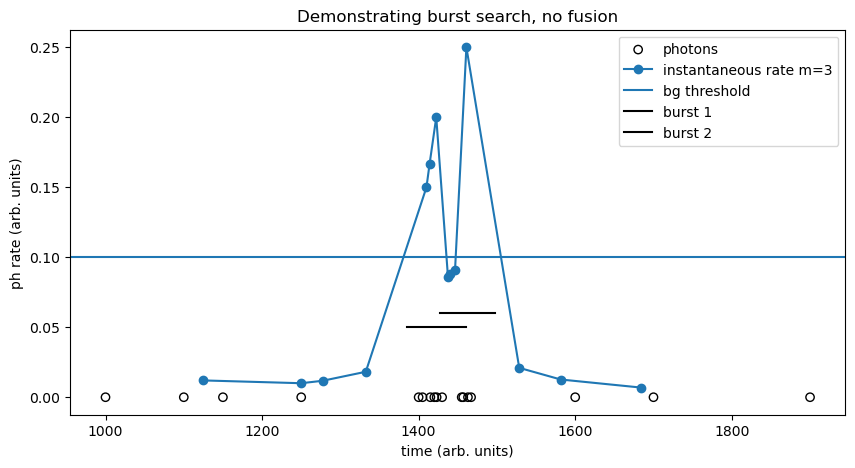

In [4]:
m = 3
F = 10.0
# "theoretical set of photon times"
photons = np.array([1000, 1100, 1150, 1250, 1400, 1405, 1415, 1420, 1423, 1430, 1455, 1457, 1463, 1467, 1600, 1700, 1900])
bgr = 1/100 # background separation is typically ~100
sw = photons[m:] - photons[:-m]
fig = plt.figure(figsize=(10,5))
plt.scatter(photons, np.zeros(photons.size), ec='k', c='none', label='photons', marker='o', )
plt.plot(photons[:-m]+sw/2, m/sw, marker='o', label=f'instantaneous rate m={m}')
plt.axhline(bgr*F, label='bg threshold')

# code for performing burst search, first section just creates necessary context
periods = np.array([photons.min()-10, photons.max() + 10])
dets = np.zeros(photons.size, dtype=np.uint8) # detectors indexes
det_ids = np.array([0,], dtype=np.uint8) # detectors to treat as part of burst search
bgr = np.array([bgr,])
# burst search function
starts, stops = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=False)
# plot burst ranges
for i, (pos, start, stop) in enumerate(zip(np.arange(0.05, starts.size, 0.01), starts, stops)):
    plt.plot([start, stop], [pos, pos], c='k', label=f'burst {i+1}')

plt.xlabel("time (arb. units)")
plt.ylabel("ph rate (arb. units)")
plt.title("Demonstrating burst search, no fusion")
plt.legend()

However, when the `fuse` keyword is `True`, the search will automatically detect when
$b_{stop, i} < b_{start, i+1}$ and "fuse" the bursts so that $b^{\prime}_{start, j} = b_{start, i}, b^{\prime}_{start, j} = b_{stop, i+1}$

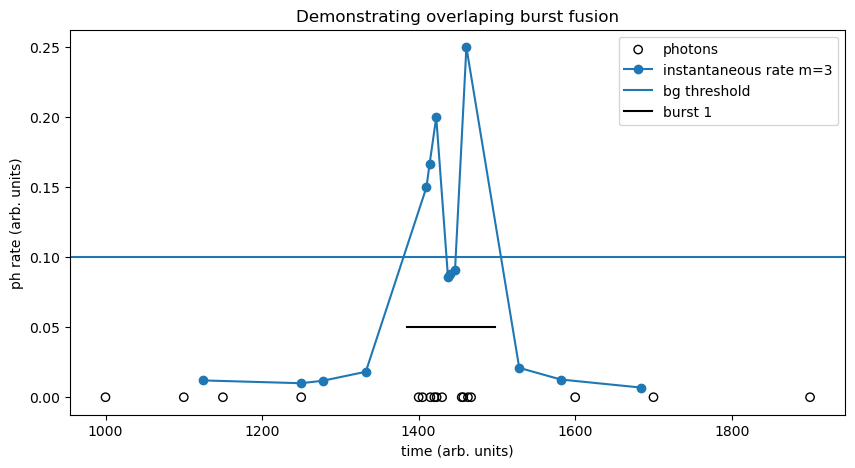

In [5]:
fig = plt.figure(figsize=(10,5))
plt.scatter(photons, np.zeros(photons.size), ec='k', c='none', label='photons', marker='o', )
plt.plot(photons[:-m]+sw/2, m/sw, marker='o', label=f'instantaneous rate m={m}')
plt.axhline(bgr*F, label='bg threshold')

# burst search function
starts, stops = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=True)
# plot burst ranges
for i, (pos, start, stop) in enumerate(zip(np.arange(0.05, starts.size, 0.01), starts, stops)):
    plt.plot([start, stop], [pos, pos], c='k', label=f'burst {i+1}')

plt.xlabel("time (arb. units)")
plt.ylabel("ph rate (arb. units)")
plt.title("Demonstrating overlaping burst fusion")
plt.legend()

It is the default to fuse bursts in this way, when creating a `Bursts` `Param`, 
this is explicitly done by setting `fuse = 0.0`,
however, as the default, it is unecessary to specify as such:

In [6]:
burst_fuse = smf.Param(smf.Bursts, 
                       params={
                           'm':10,
                           'F':6.0,
                           'streams':smf.PhSel('0ex_1ex1em'),
                           'fuse':0.0
                       },
                       parents={'bg':bg})

burst_default = smf.Param(smf.Bursts, 
                          params={
                              'm':10,
                              'F':6.0,
                              'streams':smf.PhSel('0ex_1ex1em')
                       },
                       parents={'bg':bg})

burst_fuse == burst_default

True

Fusing of bursts is also possible for closely spaced bursts.
If $b_{stop, i} + t_{fuse} < b_{start, i+1}$ the the bursts are fused: $b^{\prime}_{start, j} = b_{start, i}, b^{\prime}_{start, j} = b_{stop, i+1}$

Internally, this is done using the `cfuncs.fusebursts()` function that performs the search operation:

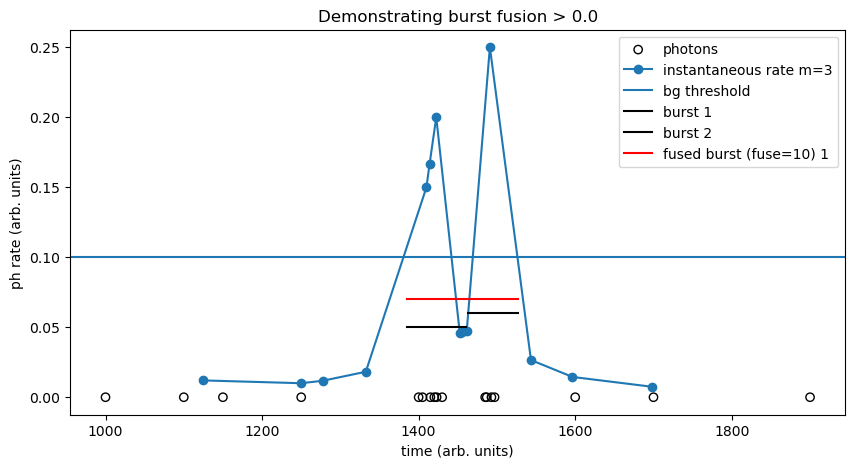

In [7]:
# "theoretical set of photon times"
m = 3
F = 10.0
photons = np.array([1000, 1100, 1150, 1250, 1400, 1405, 1415, 1420, 1423, 1430, 1485, 1487, 1493, 1497, 1600, 1700, 1900])
bgr = 1/100 # background separation is typically ~100
sw = photons[m:] - photons[:-m]

fig = plt.figure(figsize=(10,5))
plt.scatter(photons, np.zeros(photons.size), ec='k', c='none', label='photons', marker='o', )
plt.plot(photons[:-m]+sw/2, m/sw, marker='o', label=f'instantaneous rate m={m}')
plt.axhline(bgr*F, label='bg threshold')

# code for performing burst search, first section just creates necessary context
periods = np.array([photons.min()-10, photons.max() + 10])
dets = np.zeros(photons.size, dtype=np.uint8) # detectors indexes
det_ids = np.array([0,], dtype=np.uint8) # detectors to treat as part of burst search
bgr = np.array([bgr,])
# burst search function
starts, stops = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=True)
# plot burst ranges
for i, (pos, start, stop) in enumerate(zip(np.arange(0.05, starts.size, 0.01), starts, stops)):
    plt.plot([start, stop], [pos, pos], c='k', label=f'burst {i+1}')

fuse = 10
startsp, stopsp = smc.fusebursts(starts, stops, fuse)
for i, (pos, start, stop) in enumerate(zip(np.arange(0.01+pos, startsp.size, 0.01), startsp, stopsp)):
    plt.plot([start, stop], [pos, pos], c='r', label=f'fused burst (fuse={fuse}) {i+1}')

plt.xlabel("time (arb. units)")
plt.ylabel("ph rate (arb. units)")
plt.title("Demonstrating burst fusion > 0.0")
plt.legend()

Positive values of `fuse` in `Bursts` `Param`s indicate the $t_{fuse}$ (in seconds) so a parameter to fuse bursts
with a separation of less than 1 ms would be:

In [8]:
burst_fuse1ms = smf.Param(smf.Bursts, 
                         params={
                             'm':10,
                             'F':6.0,
                             'streams':smf.PhSel('0ex_1ex1em'),
                             'fuse':1e-3
                         },
                         parents={'bg':bg})

## Burst Gate

The [DCBS](https://doi.org/10.1021/jp063483n) algorithm presented the idea of an "and" gate between two burst searches.

Where two burst searches are overlapped, and only ranges of time overlapping between the two are considered.

To create such an and gate, intead of single values to each `m`, `F,` `streams`, `fuse`, and `bg` param/parent, each received a 2 element list.
Usually the same value is repeated for each list ie `m=[10,10]` and so forth, 
except for streams, where the donor excitation stream is the first element, and the acceptor excitation stream is the second.

If we examine however the created `Param`, it contains another key in the params field: `truthtable`

In [9]:
bursts_dcbs = smf.Param(smf.Bursts,
                        params={
                            'm':[10, 10],
                            'F':[6.0, 6.0],
                            'streams':[smf.PhSel('0ex'), smf.PhSel('1ex1em')],
                            'fuse':[0.0, 0.0]
                        },
                       parents={'bg':bg})
tt = bursts_dcbs.params['truthtable']
tt

array([[False, False],
       [False,  True]])

This truthtable is that of a classical "AND" gate.
Performing the AND gate is done internally (that is by the `Busrts` class) by the function `cfuncs.burstgate()`.

It's function is demonstrated below

Text(0.5, 1.0, 'Demonstration of burst AND gate')

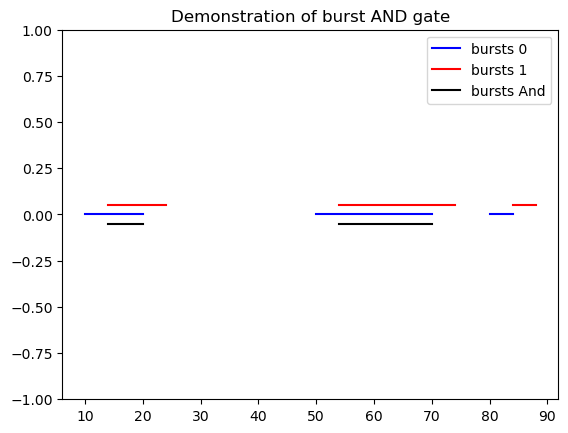

In [10]:
starts0, stops0 = np.array([[10, 50, 80], 
                            [20, 70, 84]])
setl = True
for start, stop in zip(starts0, stops0):
    if setl:
        plt.plot([start, stop], [0, 0], c='b', label='bursts 0')
        setl = False
    else:
        plt.plot([start, stop], [0, 0], c='b')

starts1, stops1 = starts0 + 4, stops0 + 4

setl = True
for start, stop in zip(starts1, stops1):
    if setl:
        plt.plot([start, stop], [0.05, 0.05], c='r', label='bursts 1')
        setl = False
    else:
        plt.plot([start, stop], [0.05, 0.05], c='r')

# internal call to perform and gate:
startsA, stopsA = smc.burstgate([starts0, starts1], [stops0, stops1], tt)

setl = True
for start, stop in zip(startsA, stopsA):
    if setl:
        plt.plot([start, stop], [-0.05, -0.05], c='k', label='bursts And')
        setl = False
    else:
        plt.plot([start, stop], [-0.05, -0.05], c='k')

plt.ylim([-1.0, 1.0])
plt.legend()
plt.title("Demonstration of burst AND gate")

Note the last argument to `cfuncs.burstgate()`.
This is the truthtable for the AND operator, which behaves in a way analagous to the truthtable of `Gates`, 
see the documentation on [gates](GatesTutorial.ipynb).

This means that it is possible to for instance use an OR gate instead to take all time ranges
encompased by both:

Text(0.5, 1.0, 'Demonstration of burst OR gate')

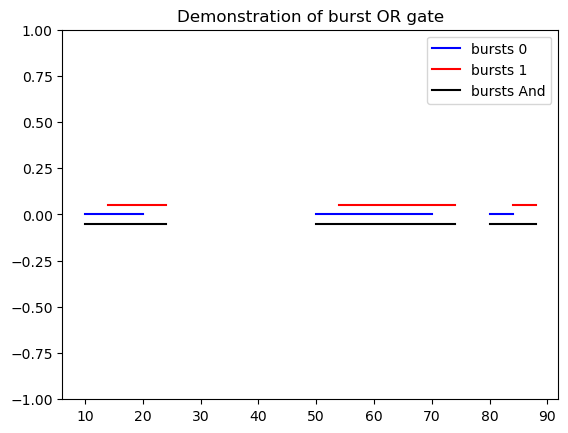

In [11]:
ttOR = np.array([[False, True],[True, True]])

setl = True
for start, stop in zip(starts0, stops0):
    if setl:
        plt.plot([start, stop], [0, 0], c='b', label='bursts 0')
        setl = False
    else:
        plt.plot([start, stop], [0, 0], c='b')

setl = True
for start, stop in zip(starts1, stops1):
    if setl:
        plt.plot([start, stop], [0.05, 0.05], c='r', label='bursts 1')
        setl = False
    else:
        plt.plot([start, stop], [0.05, 0.05], c='r')



startsA, stopsA = smc.burstgate([starts0, starts1], [stops0, stops1], ttOR)

setl = True
for start, stop in zip(startsA, stopsA):
    if setl:
        plt.plot([start, stop], [-0.05, -0.05], c='k', label='bursts And')
        setl = False
    else:
        plt.plot([start, stop], [-0.05, -0.05], c='k')

plt.ylim([-1.0, 1.0])
plt.legend()
plt.title("Demonstration of burst OR gate")

We can create a `Bursts` based `Param` with an OR gate in the following way:

In [12]:
bursts_ORbs = smf.Param(smf.Bursts,
                        params={
                            'm':[10, 10],
                            'F':[6.0, 6.0],
                            'streams':[smf.PhSel('0ex'), smf.PhSel('1ex1em')],
                            'fuse':[0.0, 0.0],
                            'truthtable':np.array([[False, True],[True,True]])
                        },
                       parents={'bg':[bg, bg]})
ttOR = bursts_ORbs.params['truthtable']
ttOR

array([[False,  True],
       [ True,  True]])

### 3 or more streams

In the case of standard ALEX/PIE measuremnts, there is rarely a need to go beyond 2 streams,
however, especially for MFD and multi-spectral measurements, burst gating is not restricted to just 1 or 2 burst searches.

Note that the dimensionality of the truthtable grows with the number of burst searches, but every dimension is always size 2:

In [13]:
np.array([[[False, False],[False, False]],[[False, False],[False, True]]])

array([[[False, False],
        [False, False]],

       [[False, False],
        [False,  True]]])

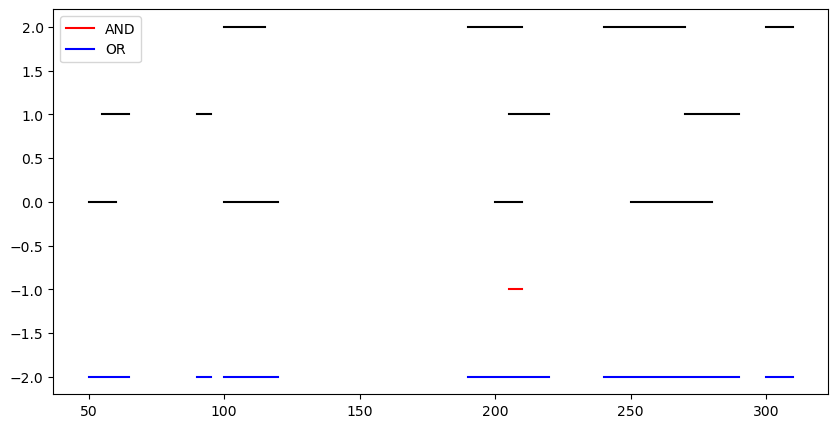

In [14]:
starts0 = np.array([ 50, 100, 200, 250])
stops0  = np.array([ 60, 120, 210, 280])

starts1 = np.array([ 55,  90, 205, 270])
stops1  = np.array([ 65,  95, 220, 290])

starts2 = np.array([100, 190, 240, 300])
stops2  = np.array([115, 210, 270, 310])

plt.figure(figsize=(10,5))
for i, (starts, stops) in enumerate(zip((starts0, starts1, starts2), (stops0, stops1, stops2))):
    for startstop in zip(starts, stops):
        plt.plot(startstop, [i, i], c='k')

# AND gate
startA, stopA = smc.burstgate([starts0, starts1, starts2], [stops0, stops1, stops2], np.array([[[False, False],[False, False]],[[False, False],[False, True]]]))
setl = True
for startstop in zip(startA, stopA):
    if setl:
        plt.plot(startstop, [-1, -1], c='r', label='AND')
        setl = False
    else:
        plt.plot(startstop, [-1, -1], c='r')

# OR gate
startA, stopA = smc.burstgate([starts0, starts1, starts2], [stops0, stops1, stops2], np.array([[[False, True],[True, True]],[[True, True],[True, True]]]))
setl = True
for startstop in zip(startA, stopA):
    if setl:
        plt.plot(startstop, [-2, -2], c='b', label='OR')
        setl = False
    else:
        plt.plot(startstop, [-2, -2], c='b')

plt.legend()

### Default multi-AND gate

If truthtable is not specified, `Bursts` assumes it is an "all AND" gate, 
and if a given parameter is specified as a single value, it gets "broadcast" to the number of burst searches used:

In [15]:
bursts_3bs = smf.Param(smf.Bursts,
                       params={
                           'm':10,
                           'F':[6.0, 10.0, 6.0],
                           'streams':[smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')],
                        },
                       parents={'bg':bg})
bursts_3bs.params['truthtable'], bursts_3bs.params['m']

(array([[[False, False],
         [False, False]],
 
        [[False, False],
         [False,  True]]]),
 array([10, 10, 10]))

### multi-OR gate

It is also possible to create an "all OR" (True everywhere except when not in any burst)
by passing the string `'or'` to `truthtable`:

In [16]:
bursts_3ORbs = smf.Param(smf.Bursts,
                         params={
                             'm':10,
                             'F':[6.0, 10.0, 6.0],
                             'streams':[smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')],
                             'truthtable':'or'
                         },
                         parents={'bg':bg})
bursts_3ORbs.params['truthtable']

array([[[False,  True],
        [ True,  True]],

       [[ True,  True],
        [ True,  True]]])

### Inverted gates

A final feature of the truthtable is the ability to invert a burst search.

That is, take the time ranges in between bursts, simply by maketing the truthtable `[True, False]`:

In [17]:
burst_INV = smf.Param(smf.Bursts, 
                      params={
                          'm':10, 'F':6.0, 
                          'streams':smf.PhSel('0ex'), 
                          'truthtable':np.array([True, False])},
                      parents={'bg':bg})

Let's demonstrate this with our line plots:

(-1.0, 1.0)

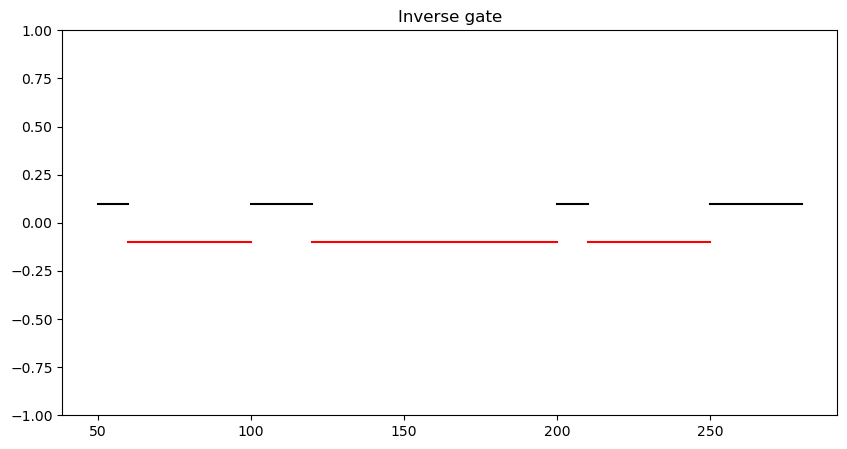

In [18]:
plt.figure(figsize=(10,5))
for startstop in zip(starts0, stops0):
    plt.plot(startstop, [0.1, 0.1], c='k')

startsI, stopsI = smc.burstgate([starts0,], [stops0,], np.array([True, False]))

for startstop in zip(startsI, stopsI):
    plt.plot(startstop, [-0.1, -0.1], c='r')

plt.title("Inverse gate")
plt.ylim([-1,1])